# BDA601 Assessment 2 - Visualisation and Model Development
### Predicting telecommunications customer churn with a PySpark MLlib decision tree

| Item | Detail |
|---|---|
| Student | Luis Faria |
| Subject | BDA601 - Big Data and Analytics |
| Assessment | Assessment 2 - Visualisation and Model Development |
| Dataset | Telco Customer Churn (IBM sample, via Kaggle), modified to 16 attributes |
| Target | `Churn` (Yes / No) |
| Engine | Apache Spark MLlib (`pyspark.ml`) decision tree; pandas + seaborn for EDA |
| Weighting | 30% |

**Problem in one line:** retaining a customer is far cheaper than acquiring a new one, so this
notebook builds and interprets a decision-tree model that flags which subscribers are likely to
churn, using big-data tooling (Spark) end to end.

## 0. Setup and Spark session

We pin the PySpark worker to the same Python that runs this kernel (Python 3.11) so the driver and
executors match, point Spark at the local Java 8 runtime, and fix a global random seed for
reproducibility.

In [1]:
import os, sys, json, warnings, re
from pathlib import Path

# Pin Spark's Python workers to THIS interpreter (driver == executor) and locate Java 8.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ.setdefault("JAVA_HOME", "/Library/Internet Plug-Ins/JavaAppletPlugin.plugin/Contents/Home")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Resolve paths whether the notebook runs from notebook/ or the assessment root.
CWD = Path.cwd()
ASSESS = CWD if (CWD / "dataset").exists() else CWD.parent
DATA_DIR = ASSESS / "dataset"
OUT_DIR = ASSESS / "outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RAW_CSV = DATA_DIR / "Telco-Customer-Churn.csv"
MOD_CSV = DATA_DIR / "Telco-Customer-Churn-16attr.csv"
print("Assessment dir:", ASSESS)
print("Raw dataset   :", RAW_CSV.exists(), RAW_CSV)

Assessment dir: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/BDA/assignments/Assessment2
Raw dataset   : True /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/BDA/assignments/Assessment2/dataset/Telco-Customer-Churn.csv


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("BDA601-A2-Churn")
         .master("local[*]")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.ui.enabled", "false")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

26/07/07 06:56:53 WARN Utils: Your hostname, Luiss-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.0.3 instead (on interface en0)
26/07/07 06:56:53 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/07 06:56:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.3


## 1. Problem Statement

Customer churn (attrition) is the movement of customers from one provider to another. Because
acquiring a new customer costs materially more than retaining an existing one, and long-tenured
customers are cheaper to serve and less price-sensitive, accurately predicting *who will churn*
lets a telco target retention spend where it matters (EMC Education Services, 2015).

**Objective.** Build a decision-tree classifier that predicts the binary `Churn` label from a
customer's account, service and demographic attributes, then interpret *who* is churning and *how
well* the model performs. The decision tree is chosen because it is interpretable - the retention
team can read the splits as plain business rules - while still capturing non-linear interactions.

**Data.** A modified IBM/Kaggle Telco sample: 7,043 customers and (after construction) 16 attributes,
with `Churn` as the last column (Kaggle, 2020).

## 2. Task 1 - Dataset construction

The brief requires removing five attributes - `MonthlyCharges`, `OnlineSecurity`, `StreamingTV`,
`InternetService`, `Partner` - leaving 7,043 observations and 16 attributes. We do this
programmatically (reproducible), assert the resulting shape, and save the modified CSV that is part
of the submission bundle.

In [3]:
DROP_COLS = ["MonthlyCharges", "OnlineSecurity", "StreamingTV", "InternetService", "Partner"]

raw = pd.read_csv(RAW_CSV)
print("Original shape:", raw.shape)

df16 = raw.drop(columns=DROP_COLS)
assert df16.shape == (7043, 16), f"unexpected shape {df16.shape}"
assert df16.columns[-1] == "Churn", "Churn must be the last column"
df16.to_csv(MOD_CSV, index=False)
print("Modified shape:", df16.shape, "-> saved", MOD_CSV.name)
df16.head()

Original shape: (7043, 21)
Modified shape: (7043, 16) -> saved Telco-Customer-Churn-16attr.csv


,customerID,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,OnlineBackup,DeviceProtection,TechSupport,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,0,No,1,No,No phone service,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,34,Yes,No,No,Yes,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,0,No,2,Yes,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,0,No,45,No,No phone service,No,Yes,Yes,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,0,No,2,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes


## 3. Exploratory Data Analysis

We explore the 16-attribute dataset with both **statistical** summaries (measures of central tendency
and dispersion) and **visual** representations (bar, histogram, box, heatmap, pair plot), and record
the insights that will shape cleaning, feature selection and the churn interpretation.

In [4]:
df = pd.read_csv(MOD_CSV)

# TotalCharges is read as text because 11 rows carry a blank space -> coerce to numeric to expose NaNs.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# SeniorCitizen is a binary category, not a continuous measurement.
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"}).astype("category")
print("Missing values per column (non-zero only):")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nThe", int(df['TotalCharges'].isna().sum()), "missing TotalCharges all have tenure == 0:",
      df.loc[df['TotalCharges'].isna(), 'tenure'].unique())

Missing values per column (non-zero only):
TotalCharges    11
dtype: int64

The 11 missing TotalCharges all have tenure == 0: [0]


In [5]:
# Central tendency AND dispersion for genuine numeric features.
num_cols = ["tenure", "TotalCharges"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["variance"] = df[num_cols].var()
desc["range"] = df[num_cols].max() - df[num_cols].min()
print("Numeric summary (central tendency: mean/median; dispersion: std/variance/range):")
desc.round(2)

Numeric summary (central tendency: mean/median; dispersion: std/variance/range):


,count,mean,std,min,25%,50%,75%,max,median,variance,range
tenure,7043.0,32.37,24.56,0.0,9.00,29.00,55.00,72.0,29.00,603.17,72.0
TotalCharges,7032.0,2283.30,2266.77,18.8,401.45,1397.48,3794.74,8684.8,1397.48,5138252.41,8666.0


In [6]:
# Categorical levels and the modal category (central tendency for categoricals).
cat_cols = [c for c in df.columns if c not in num_cols + ["customerID", "Churn"]]
for c in cat_cols:
    vc = df[c].value_counts()
    print(f"{c:18s} | levels={df[c].nunique()} | mode='{vc.index[0]}' ({vc.iloc[0]})")

gender             | levels=2 | mode='Male' (3555)
SeniorCitizen      | levels=2 | mode='No' (5901)
Dependents         | levels=2 | mode='No' (4933)
PhoneService       | levels=2 | mode='Yes' (6361)
MultipleLines      | levels=3 | mode='No' (3390)
OnlineBackup       | levels=3 | mode='No' (3088)
DeviceProtection   | levels=3 | mode='No' (3095)
TechSupport        | levels=3 | mode='No' (3473)
StreamingMovies    | levels=3 | mode='No' (2785)
Contract           | levels=3 | mode='Month-to-month' (3875)
PaperlessBilling   | levels=2 | mode='Yes' (4171)
PaymentMethod      | levels=4 | mode='Electronic check' (2365)


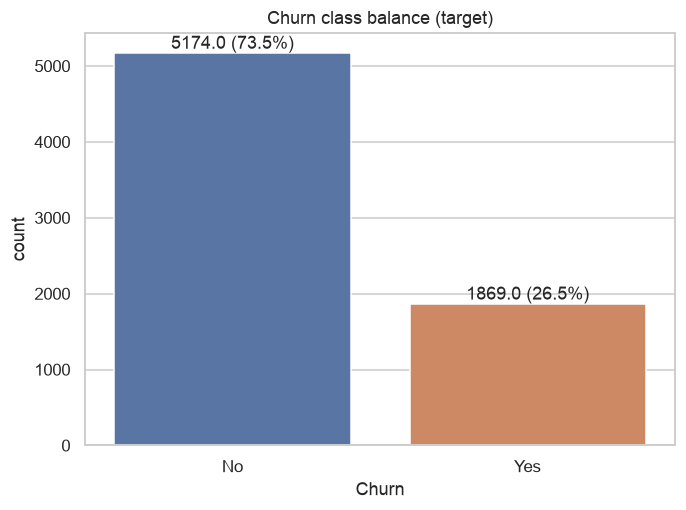

Base rate -> No: 73.5% | Yes: 26.5%


In [7]:
# 3.1 Target balance - the dataset is imbalanced, which frames the whole evaluation.
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False)
total = len(df)
for p in ax.patches:
    ax.annotate(f"{p.get_height()} ({p.get_height()/total:.1%})",
                (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax.set_title("Churn class balance (target)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig01_churn_balance.png"); plt.show()
base_rate = df["Churn"].value_counts(normalize=True)
print("Base rate -> No: {:.1%} | Yes: {:.1%}".format(base_rate.get("No"), base_rate.get("Yes")))

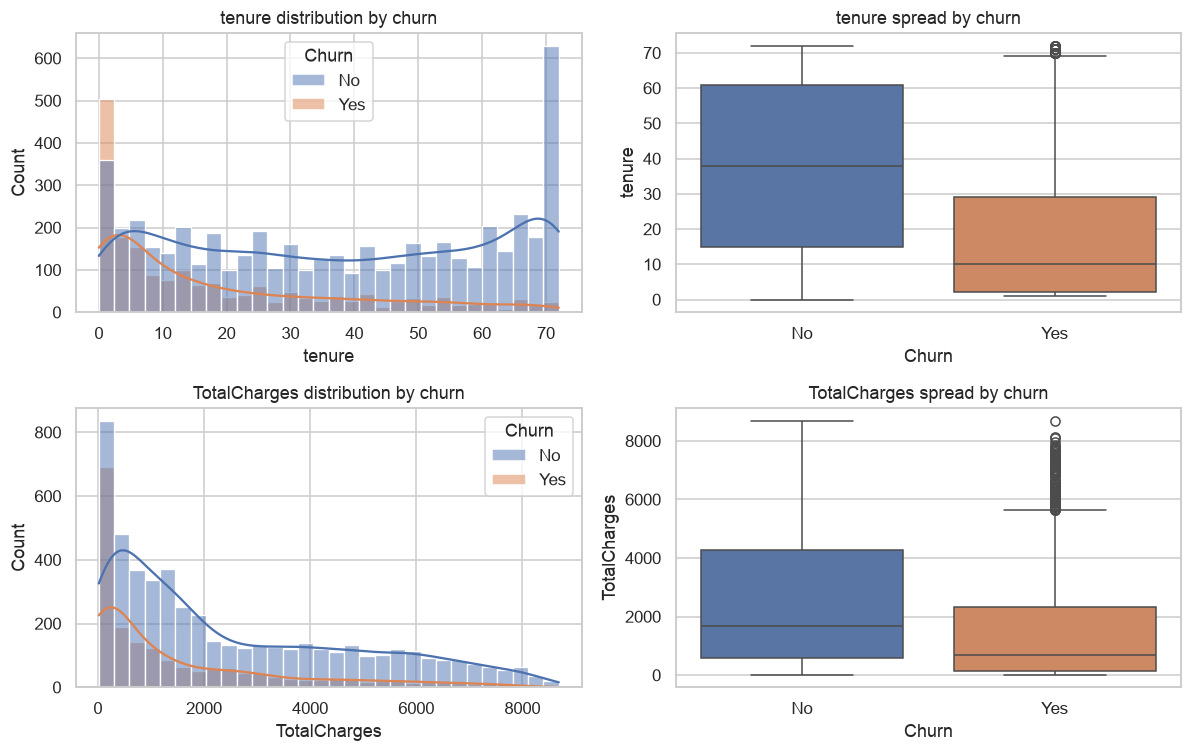

Median tenure  -> churn: 10.0 | stay: 38.0


In [8]:
# 3.2 Numeric distributions vs churn - tenure and TotalCharges (histogram + box plot).
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("tenure distribution by churn")
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("tenure spread by churn")
sns.histplot(data=df, x="TotalCharges", hue="Churn", bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("TotalCharges distribution by churn")
sns.boxplot(data=df, x="Churn", y="TotalCharges", hue="Churn", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("TotalCharges spread by churn")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig02_numeric_by_churn.png"); plt.show()
print("Median tenure  -> churn:", df[df.Churn=='Yes'].tenure.median(), "| stay:", df[df.Churn=='No'].tenure.median())

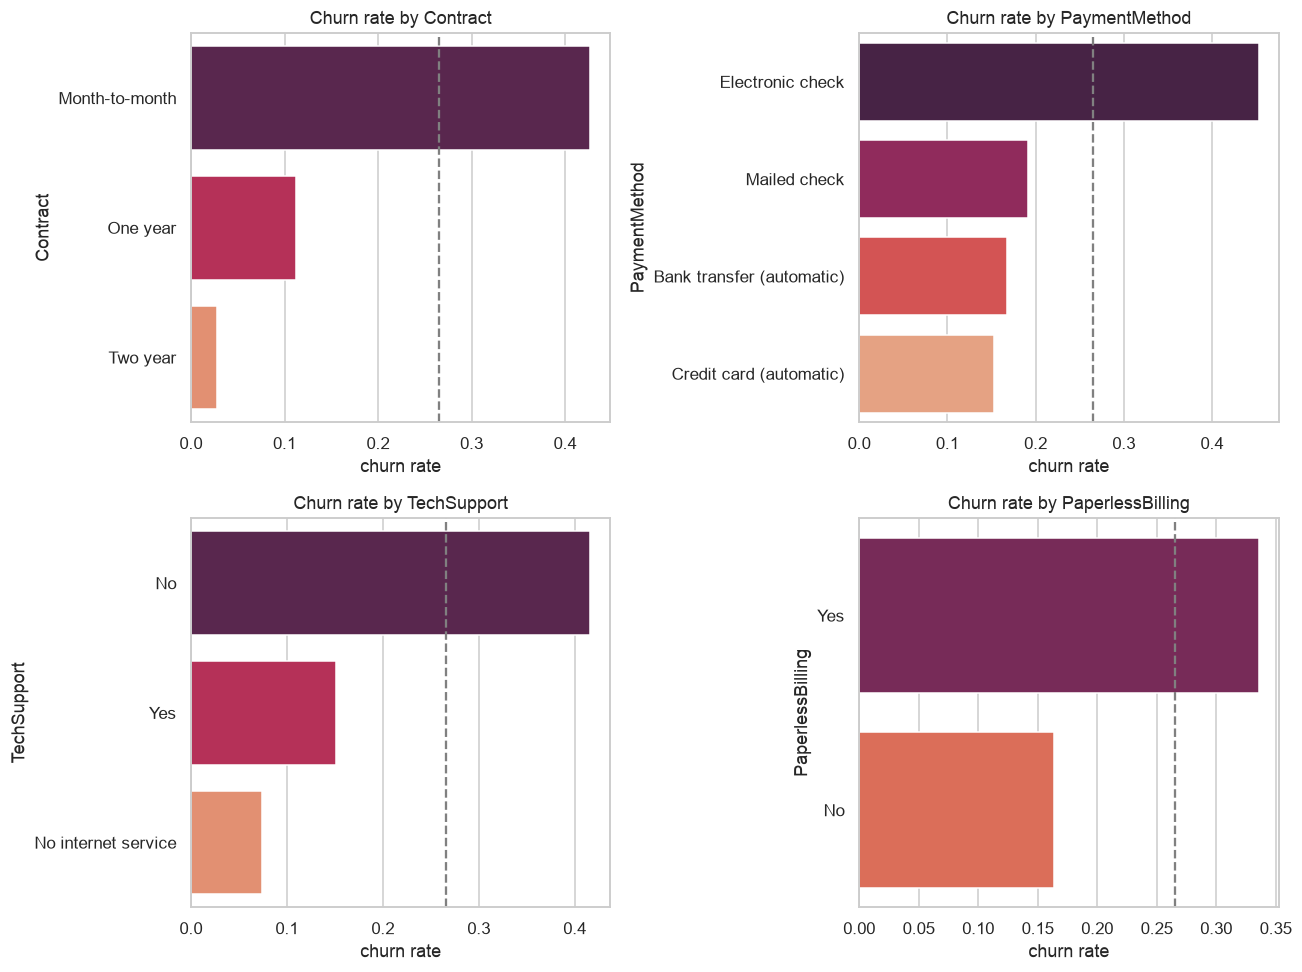

In [9]:
# 3.3 Churn rate across key categorical drivers.
driver_cols = ["Contract", "PaymentMethod", "TechSupport", "PaperlessBilling"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), driver_cols):
    rate = (df.assign(churn=(df.Churn == "Yes").astype(int))
              .groupby(col)["churn"].mean().sort_values(ascending=False))
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, palette="rocket", legend=False, ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("churn rate"); ax.axvline(base_rate.get("Yes"), ls="--", c="grey")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig03_categorical_churn_rate.png"); plt.show()

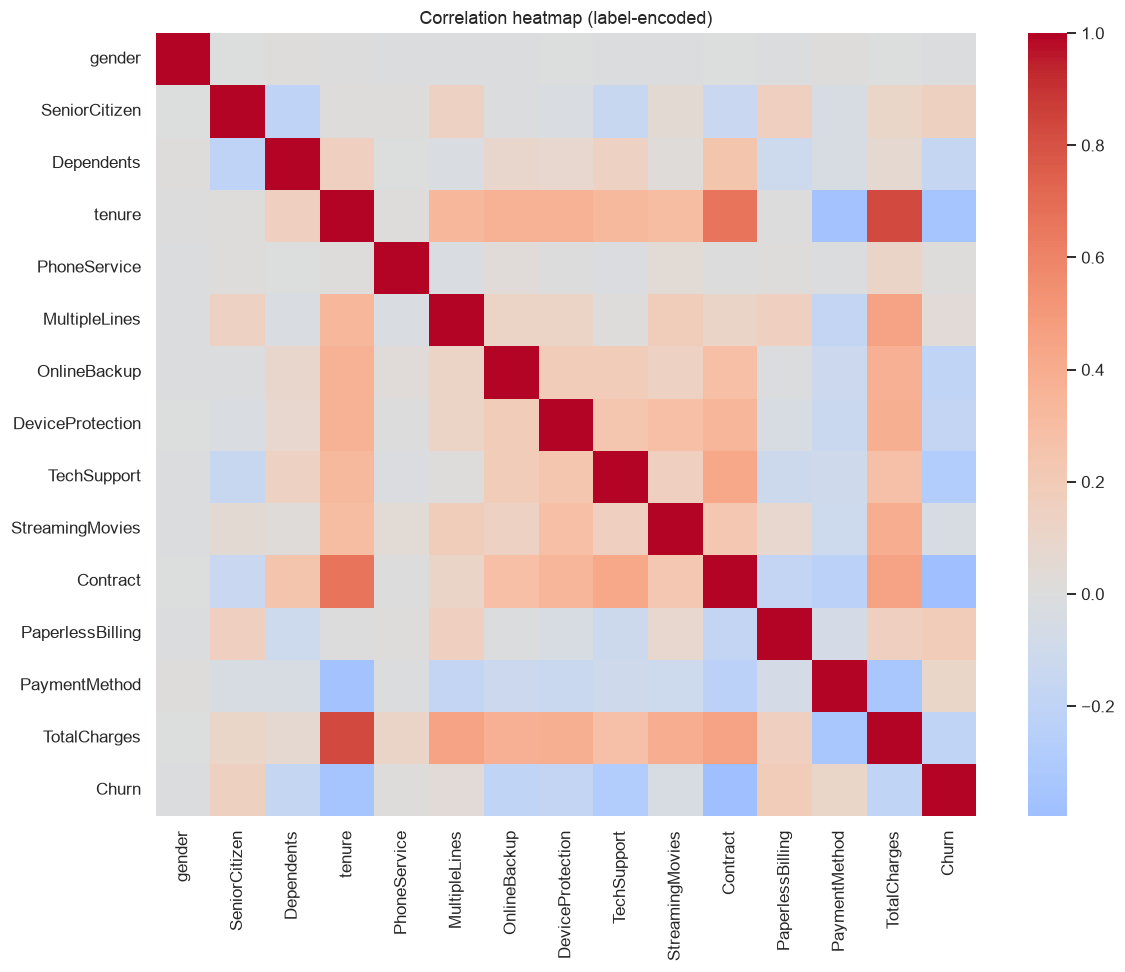

tenure vs TotalCharges correlation = 0.826  (redundancy flag)


In [10]:
# 3.4 Correlation heatmap (numeric + label-encoded categoricals) to spot redundancy.
enc = df.drop(columns=["customerID"]).copy()
enc["TotalCharges"] = enc["TotalCharges"].fillna(0)
for c in enc.select_dtypes(include=["object", "category"]).columns:
    enc[c] = enc[c].astype("category").cat.codes
plt.figure(figsize=(11, 9))
sns.heatmap(enc.corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap (label-encoded)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig04_correlation_heatmap.png"); plt.show()
tc_corr = enc["tenure"].corr(enc["TotalCharges"])
print(f"tenure vs TotalCharges correlation = {tc_corr:.3f}  (redundancy flag)")

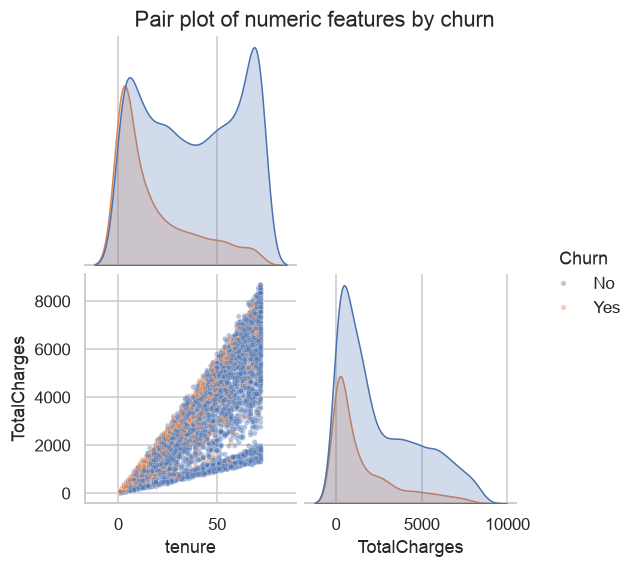

In [11]:
# 3.5 Pair plot of the numeric features, coloured by churn.
pp = sns.pairplot(df[num_cols + ["Churn"]].dropna(), hue="Churn", corner=True,
                  plot_kws={"alpha": 0.4, "s": 12})
pp.fig.suptitle("Pair plot of numeric features by churn", y=1.02)
pp.savefig(FIG_DIR / "fig05_pairplot.png"); plt.show()

**EDA insights.**

- **Imbalance.** Only ~26.5% of customers churn, so a model that always predicts *No* already scores
  ~73.5% accuracy. Accuracy alone is therefore misleading - recall on the churn class, F1 and AUC must
  drive the evaluation.
- **Tenure is the strongest signal.** Churners are heavily concentrated at low tenure (the first few
  months); long-tenured customers rarely leave.
- **Contract type dominates the categoricals.** Month-to-month contracts churn far above the base
  rate, while one- and two-year contracts churn well below it. Electronic-check payment, paperless
  billing and lack of tech support also lift churn.
- **Redundancy.** `tenure` and `TotalCharges` are strongly correlated (longer tenure accumulates more
  charges), which we note for feature selection.
- **Data quality.** Exactly 11 `TotalCharges` values are blank, all for brand-new customers
  (`tenure == 0`); these are handled in the next section.

## 4. Data cleaning and feature selection

Steps: (1) handle the data anomaly in `TotalCharges`; (2) run the redundancy / correlation analysis;
(3) select features and justify the choice; (4) assemble a Spark ML pipeline that indexes the
categoricals, marks them as categorical for the tree, and vectorises the predictors.

In [12]:
# (1) Data-quality diagnostics and domain-informed anomaly handling.
clean = df.copy()
duplicate_rows = int(clean.duplicated().sum())
duplicate_ids = int(clean["customerID"].duplicated().sum())
blank_totalcharges = int(clean["TotalCharges"].isna().sum())
assert clean.loc[clean["TotalCharges"].isna(), "tenure"].eq(0).all()
# A tenure-zero customer has not accumulated charges; zero is coherent, unlike a mature-customer median.
clean["TotalCharges"] = clean["TotalCharges"].fillna(0.0)

outlier_counts = {}
for col in ["tenure", "TotalCharges"]:
    q1, q3 = clean[col].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((clean[col] < lo) | (clean[col] > hi)).sum())
print("Exact duplicate rows:", duplicate_rows, "| duplicate customerID:", duplicate_ids)
print(f"Blank TotalCharges corrected to zero: {blank_totalcharges}")
print("IQR outlier flags (diagnostic only; valid customers retained):", outlier_counts)
print("Remaining missing values:", int(clean.isna().sum().sum()))

# (2) Candidate feature sets for the redundancy ablation below.
NUMERIC_FULL = ["tenure", "TotalCharges"]
CATEGORICAL_FULL = [c for c in clean.columns if c not in NUMERIC_FULL + ["customerID", "Churn"]]
data_quality = {"duplicate_rows": duplicate_rows, "duplicate_customer_ids": duplicate_ids,
                "blank_totalcharges_set_to_zero": blank_totalcharges, "iqr_outlier_flags": outlier_counts}
print(f"\n{len(NUMERIC_FULL)} numeric + {len(CATEGORICAL_FULL)} categorical = "
      f"{len(NUMERIC_FULL)+len(CATEGORICAL_FULL)} candidate predictors")

Exact duplicate rows: 0 | duplicate customerID: 0
Blank TotalCharges corrected to zero: 11
IQR outlier flags (diagnostic only; valid customers retained): {'tenure': 0, 'TotalCharges': 0}
Remaining missing values: 0

2 numeric + 12 categorical = 14 candidate predictors


In [13]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, VectorIndexer
from pyspark.ml.functions import vector_to_array
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import functions as F
from pyspark.sql.window import Window

sdf = spark.createDataFrame(clean)

# Deterministic and label-stratified 60/20/20 partitioning using customerID.
w = Window.partitionBy("Churn").orderBy(F.xxhash64("customerID", F.lit(RANDOM_SEED)))
wc = Window.partitionBy("Churn")
split_raw = (sdf.withColumn("_rn", F.row_number().over(w))
                .withColumn("_n", F.count("*").over(wc))
                .withColumn("_p", F.col("_rn") / F.col("_n"))
                .withColumn("split", F.when(F.col("_p") <= 0.60, "train")
                                      .when(F.col("_p") <= 0.80, "validation")
                                      .otherwise("test"))
                .drop("_rn", "_n", "_p").cache())
train_raw = split_raw.filter("split = 'train'").drop("split").cache()
val_raw = split_raw.filter("split = 'validation'").drop("split").cache()
test_raw = split_raw.filter("split = 'test'").drop("split").cache()

split_summary = (split_raw.groupBy("split", "Churn").count().toPandas()
                 .sort_values(["split", "Churn"]).reset_index(drop=True))
split_ids = {name: set(frame.select("customerID").toPandas()["customerID"])
             for name, frame in {"train": train_raw, "validation": val_raw, "test": test_raw}.items()}
assert not (split_ids["train"] & split_ids["validation"] or split_ids["train"] & split_ids["test"]
            or split_ids["validation"] & split_ids["test"])
assert len(set.union(*split_ids.values())) == len(clean)
print(split_summary.to_string(index=False))

def make_preprocessor(numeric, categorical):
    cat_indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep",
                                  stringOrderType="alphabetAsc") for c in categorical]
    label_indexer = StringIndexer(inputCol="Churn", outputCol="label", handleInvalid="error",
                                  stringOrderType="alphabetAsc")  # No=0, Yes=1, stable across runs
    assembler = VectorAssembler(inputCols=numeric + [c + "_idx" for c in categorical],
                                outputCol="features_raw", handleInvalid="error")
    vindexer = VectorIndexer(inputCol="features_raw", outputCol="features",
                             maxCategories=12, handleInvalid="keep")
    return Pipeline(stages=cat_indexers + [label_indexer, assembler, vindexer])

def churn_f1(pred):
    cm = {(float(r["label"]), float(r["prediction"])): int(r["count"])
          for r in pred.groupBy("label", "prediction").count().collect()}
    tp, fp, fn = cm.get((1.0, 1.0), 0), cm.get((0.0, 1.0), 0), cm.get((1.0, 0.0), 0)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    return 2 * precision * recall / (precision + recall) if precision + recall else 0.0

# Redundancy ablation: retain TotalCharges only if it adds material validation value.
auc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="p_churn",
                                          metricName="areaUnderROC")
def probability_auc(pred):
    return auc_eval.evaluate(pred.withColumn("p_churn", vector_to_array("probability")[1]))
ablation_rows, ablation_models = [], {}
for name, numeric in [("full", NUMERIC_FULL), ("without_TotalCharges", ["tenure"])]:
    prep_candidate = make_preprocessor(numeric, CATEGORICAL_FULL).fit(train_raw)
    tr = prep_candidate.transform(train_raw).select("customerID", "features", "label")
    va = prep_candidate.transform(val_raw).select("customerID", "features", "label")
    candidate = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=5,
                                       seed=RANDOM_SEED).fit(tr)
    vp = candidate.transform(va)
    row = {"feature_set": name, "validation_auc": float(probability_auc(vp)),
           "validation_churn_f1": float(churn_f1(vp))}
    ablation_rows.append(row); ablation_models[name] = (prep_candidate, tr, va)
ablation = pd.DataFrame(ablation_rows)
full_r = ablation.set_index("feature_set").loc["full"]
red_r = ablation.set_index("feature_set").loc["without_TotalCharges"]
drop_redundant = (red_r.validation_auc >= full_r.validation_auc - 0.005 and
                  red_r.validation_churn_f1 >= full_r.validation_churn_f1 - 0.01)
selected_set = "without_TotalCharges" if drop_redundant else "full"
NUMERIC = ["tenure"] if drop_redundant else NUMERIC_FULL
CATEGORICAL = CATEGORICAL_FULL
FEATURE_NAMES = NUMERIC + CATEGORICAL

# Fit the final preprocessing pipeline on training only, then transform validation/test.
prep = make_preprocessor(NUMERIC, CATEGORICAL).fit(train_raw)
def prepared(frame):
    return prep.transform(frame).select("customerID", "features", "label", "Churn").cache()
train_df, val_df, test_df = prepared(train_raw), prepared(val_raw), prepared(test_raw)
feature_selection = {"tenure_totalcharges_corr": round(float(tc_corr), 3),
                     "ablation": ablation.round(4).to_dict(orient="records"),
                     "selected_feature_set": selected_set, "selected_features": FEATURE_NAMES}
print(ablation.round(4).to_string(index=False))
print("Selected feature set:", selected_set, "| predictors:", len(FEATURE_NAMES))
print("train/validation/test:", train_df.count(), val_df.count(), test_df.count())

     split Churn  count
      test    No   1035
      test   Yes    374
     train    No   3104
     train   Yes   1121
validation    No   1035
validation   Yes    374


Java HotSpot(TM) 64-Bit Server VM warning: CodeCache is full. Compiler has been disabled.
Java HotSpot(TM) 64-Bit Server VM warning: Try increasing the code cache size using -XX:ReservedCodeCacheSize=


CodeCache: size=131072Kb used=45825Kb max_used=45939Kb free=85246Kb
 bounds [0x0000000102108000, 0x0000000104e38000, 0x000000010a108000]
 total_blobs=16444 nmethods=15437 adapters=918
 compilation: disabled (not enough contiguous free space left)


         feature_set  validation_auc  validation_churn_f1
                full          0.8084               0.5223
without_TotalCharges          0.8068               0.5200
Selected feature set: without_TotalCharges | predictors: 13


train/validation/test: 4225 1409 1409


## 5. Model building - PySpark MLlib decision tree

We split the data into **train / validation / test** (60/20/20, fixed seed). The validation set tunes
the tree depth; the held-out test set gives an unbiased performance estimate. The model is Spark
MLlib's `DecisionTreeClassifier`.

In [14]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Tune maxDepth on the validation set using churn-class F1, not majority-weighted F1.
val_scores = {}
for depth in [3, 4, 5, 6, 8]:
    m = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=depth, seed=RANDOM_SEED).fit(train_df)
    val_scores[depth] = churn_f1(m.transform(val_df))
best_depth = max(val_scores, key=val_scores.get)
print("Validation churn-F1 by depth:", {d: round(s, 4) for d, s in val_scores.items()})
print("Best maxDepth =", best_depth)

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=best_depth, seed=RANDOM_SEED)
model = dt.fit(train_df)

Validation churn-F1 by depth: {3: 0.4401, 4: 0.4401, 5: 0.52, 6: 0.5386, 8: 0.4948}
Best maxDepth = 6


In [15]:
# Evaluate the tuned model on the held-out TEST set.
pred = model.transform(test_df)
acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(pred)
wp  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision").evaluate(pred)
wr  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall").evaluate(pred)
f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(pred)
auc = probability_auc(pred)
print(f"TEST  accuracy={acc:.4f}  weightedPrecision={wp:.4f}  weightedRecall={wr:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

TEST  accuracy=0.7807  weightedPrecision=0.7703  weightedRecall=0.7807  F1=0.7736  AUC=0.8019


Confusion: TN=913 FP=122 FN=187 TP=187
Churn-class recall=0.500  precision=0.605


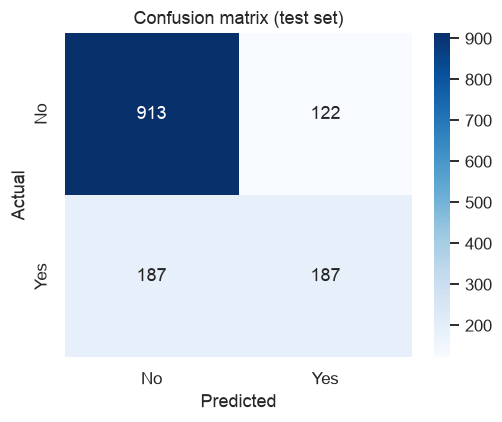

In [16]:
# Confusion matrix and churn-class precision/recall (label 1 = Yes/churn).
cm = pred.groupBy("label", "prediction").count().toPandas()
mat = cm.pivot_table(index="label", columns="prediction", values="count", fill_value=0)
mat = mat.reindex(index=[0.0, 1.0], columns=[0.0, 1.0], fill_value=0)
tn, fp = int(mat.loc[0.0, 0.0]), int(mat.loc[0.0, 1.0])
fn, tp = int(mat.loc[1.0, 0.0]), int(mat.loc[1.0, 1.0])
recall_churn = tp / (tp + fn) if (tp + fn) else 0.0
precision_churn = tp / (tp + fp) if (tp + fp) else 0.0
print(f"Confusion: TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"Churn-class recall={recall_churn:.3f}  precision={precision_churn:.3f}")

plt.figure(figsize=(4.8, 4))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix (test set)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig06_confusion_matrix.png"); plt.show()

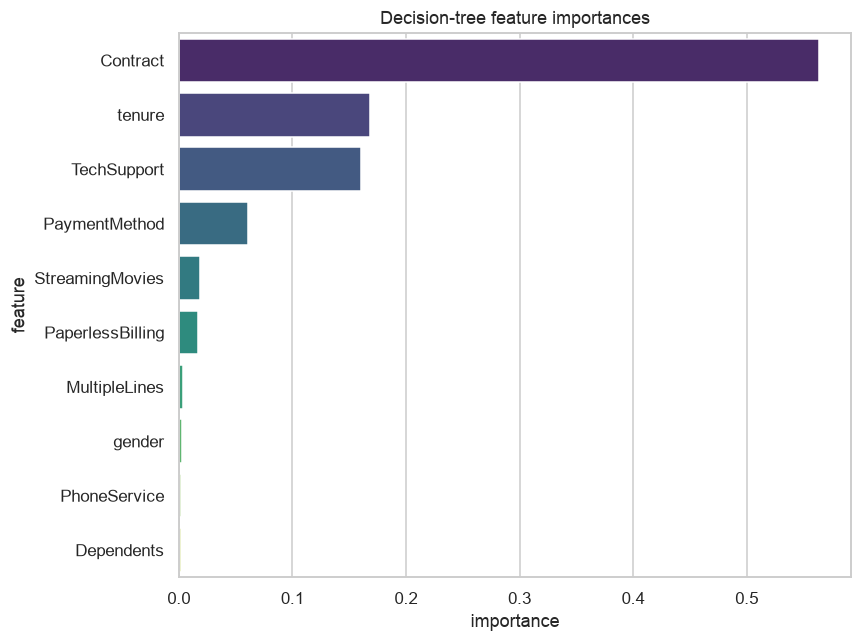

Most important attribute: Contract


,feature,importance
0,Contract,0.5640
1,tenure,0.1679
2,TechSupport,0.1604
3,PaymentMethod,0.0613
4,StreamingMovies,0.0189
5,PaperlessBilling,0.0168
6,MultipleLines,0.0038
7,gender,0.0027
8,PhoneService,0.0023
9,Dependents,0.0019


In [17]:
# Feature importances -> the most important attribute drives Task 3.
imp = sorted(zip(FEATURE_NAMES, model.featureImportances.toArray()), key=lambda x: -x[1])
imp_df = pd.DataFrame(imp, columns=["feature", "importance"])
top_feature = imp_df.iloc[0]["feature"]
plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df[imp_df.importance > 0], x="importance", y="feature", hue="feature",
            palette="viridis", legend=False)
plt.title("Decision-tree feature importances")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig07_feature_importance.png"); plt.show()
print("Most important attribute:", top_feature)
imp_df[imp_df.importance > 0].round(4)

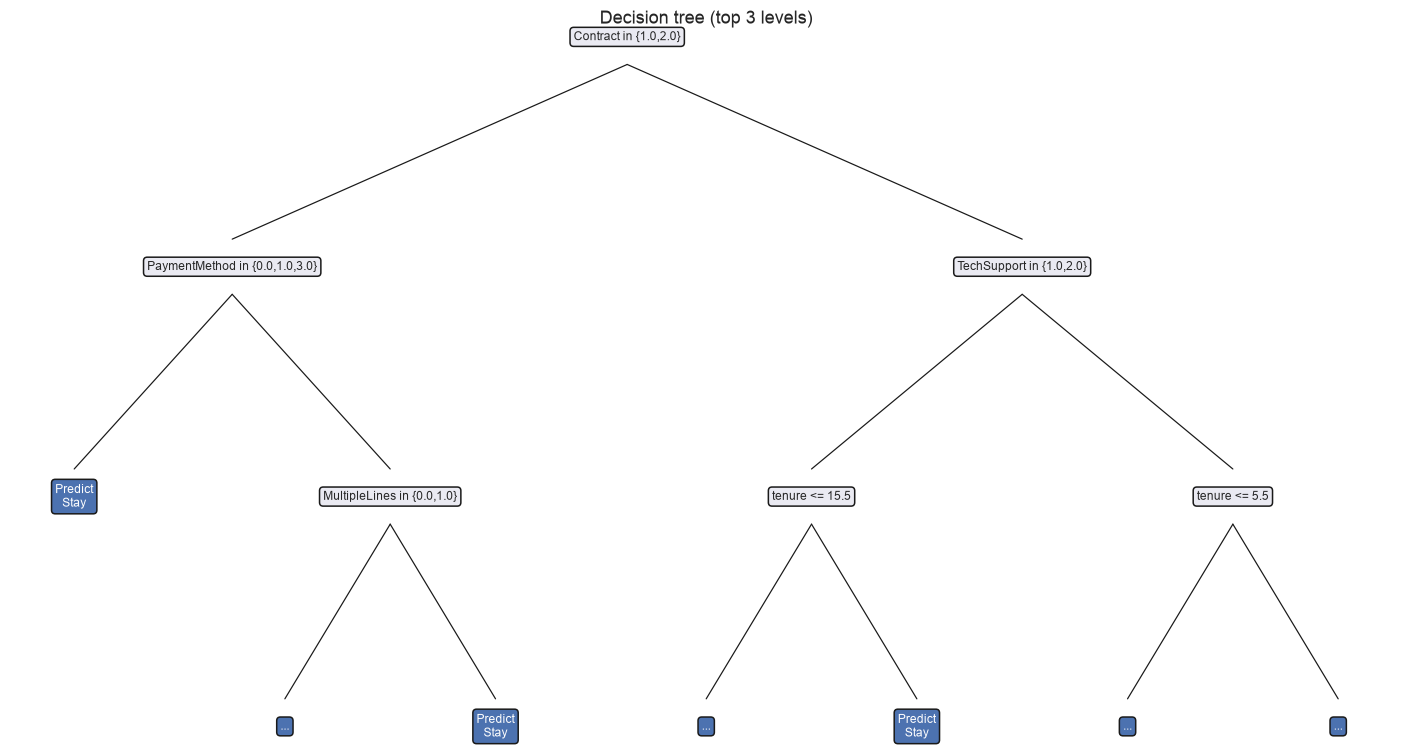

In [18]:
# Graphical decision tree, rendered from Spark's debug string with matplotlib (no graphviz needed).
def parse_spark_tree(dbg, feature_names):
    lines = [l for l in dbg.split("\n")[1:] if l.strip()]
    pos = [0]
    def parse():
        line = lines[pos[0]]; txt = line.strip(); pos[0] += 1
        if txt.startswith("Predict:"):
            return {"leaf": True, "pred": txt.split(":")[1].strip()}
        cond = txt[txt.find("(") + 1: txt.rfind(")")]
        m = re.search(r"feature (\d+)", cond)
        if m:
            cond = cond.replace(f"feature {m.group(1)}", feature_names[int(m.group(1))])
        left = parse(); pos[0] += 1; right = parse()   # skip the matching 'Else' header line
        return {"leaf": False, "cond": cond, "left": left, "right": right}
    return parse()

def draw_tree(node, max_depth=3):
    fig, ax = plt.subplots(figsize=(13, 7)); ax.axis("off")
    xcur = [0.0]
    def layout(n, depth):
        if n["leaf"] or depth == max_depth:
            x = xcur[0]; xcur[0] += 1.0; n["_x"], n["_y"] = x, -depth; return x
        lx = layout(n["left"], depth + 1); rx = layout(n["right"], depth + 1)
        n["_x"], n["_y"] = (lx + rx) / 2, -depth; return n["_x"]
    layout(node, 0)
    def render(n, depth):
        leaf = n["leaf"] or depth == max_depth
        if leaf:
            pred = n.get("pred", "subtree")
            lbl = "Predict\n" + ("Churn" if str(pred).startswith("1") else "Stay") if "pred" in n else "..."
            box = dict(boxstyle="round", fc="#DD8452" if str(n.get("pred","")).startswith("1") else "#4C72B0", ec="k")
            ax.text(n["_x"], n["_y"], lbl, ha="center", va="center", color="white", fontsize=8, bbox=box)
            return
        ax.text(n["_x"], n["_y"], n["cond"], ha="center", va="center", fontsize=8,
                bbox=dict(boxstyle="round", fc="#EAEAF2", ec="k"))
        for child, tag in [(n["left"], "T"), (n["right"], "F")]:
            ax.plot([n["_x"], child["_x"]], [n["_y"] - 0.12, child["_y"] + 0.12], "k-", lw=0.8)
            render(child, depth + 1)
    render(node, 0)
    plt.title(f"Decision tree (top {max_depth} levels)"); plt.tight_layout()
    plt.savefig(FIG_DIR / "fig08_decision_tree.png"); plt.show()

try:
    tree = parse_spark_tree(model.toDebugString, FEATURE_NAMES)
    draw_tree(tree, max_depth=3)
except Exception as e:
    print("Tree render fallback (showing text):", e)
    print(model.toDebugString[:1500])

**Model reading.** The tree's first and most important split is on the dominant attribute above;
the importance chart confirms that contract type and tenure carry most of the decision weight, matching
the EDA. The confusion matrix shows where the model trades false alarms against missed churners - the
key tension given the class imbalance.

## 5b. Optimising for recall

At the default 0.5 cut-off the interpretable tree misses nearly half of the churners. Because retention
cares far more about catching churners than about the occasional false alarm, this section keeps the
interpretable tree as the **headline model** and adds three standard remedies, then compares them on the
held-out test set: (a) **decision-threshold tuning**, (b) **class weighting**, and (c) a **Random Forest**
selected by **3-fold cross-validation**. AUC is reported per model - it is threshold-independent, so it
measures how well each model *ranks* churners regardless of the cut-off.

Decision tree: best threshold on validation = 0.26


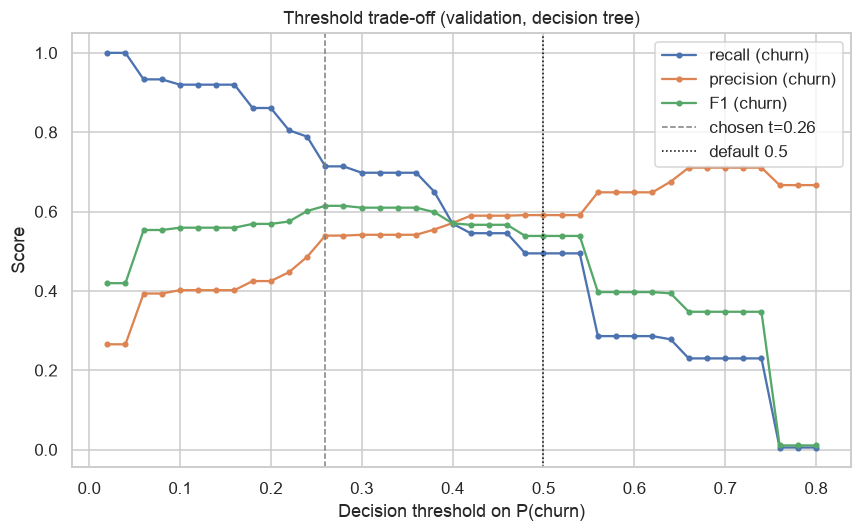

In [19]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

# Pull (label, P[churn]) to the driver so any decision threshold can be scored cheaply.
def scored(pred_df):
    return pred_df.select("label", vector_to_array("probability")[1].alias("p1")).toPandas()

def churn_scores(s, t):
    yhat = (s["p1"] >= t).astype(int); y = s["label"].astype(int)
    tp = int(((yhat == 1) & (y == 1)).sum()); fp = int(((yhat == 1) & (y == 0)).sum())
    fn = int(((yhat == 0) & (y == 1)).sum()); tn = int(((yhat == 0) & (y == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return {"acc": (tp + tn) / len(y), "precision": prec, "recall": rec, "f1": f1}

auc_cv_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction",
                                             metricName="areaUnderROC")

# (a) Tune the baseline tree's decision threshold on the VALIDATION set (maximise churn-class F1).
val_s = scored(model.transform(val_df))
grid = np.round(np.arange(0.02, 0.81, 0.02), 3)
val_curve = pd.DataFrame([{"t": t, **churn_scores(val_s, t)} for t in grid])
t_tree = float(val_curve.loc[val_curve["f1"].idxmax(), "t"])
print("Decision tree: best threshold on validation =", t_tree)

plt.figure(figsize=(8, 5))
for col, lab in [("recall", "recall (churn)"), ("precision", "precision (churn)"), ("f1", "F1 (churn)")]:
    plt.plot(val_curve["t"], val_curve[col], marker="o", ms=3, label=lab)
plt.axvline(t_tree, color="grey", ls="--", lw=1, label=f"chosen t={t_tree}")
plt.axvline(0.5, color="black", ls=":", lw=1, label="default 0.5")
plt.xlabel("Decision threshold on P(churn)"); plt.ylabel("Score")
plt.title("Threshold trade-off (validation, decision tree)")
plt.legend(); plt.tight_layout(); plt.savefig(FIG_DIR / "fig09_recall_tradeoff.png"); plt.show()

RF best params: numTrees=120  maxDepth=8


                          model  threshold  accuracy  precision_churn  recall_churn  f1_churn    auc
Decision tree (t=0.5, baseline)       0.50    0.7807           0.6052        0.5000    0.5476 0.8019
  Decision tree (t=0.26, tuned)       0.26    0.7502           0.5224        0.6845    0.5926 0.8019
          Weighted tree (t=0.5)       0.50    0.7246           0.4885        0.7968    0.6057 0.8094
      Random Forest (t=0.5, CV)       0.50    0.7935           0.6509        0.4786    0.5516 0.8334
   Random Forest (t=0.3, tuned)       0.30    0.7530           0.5242        0.7540    0.6184 0.8334


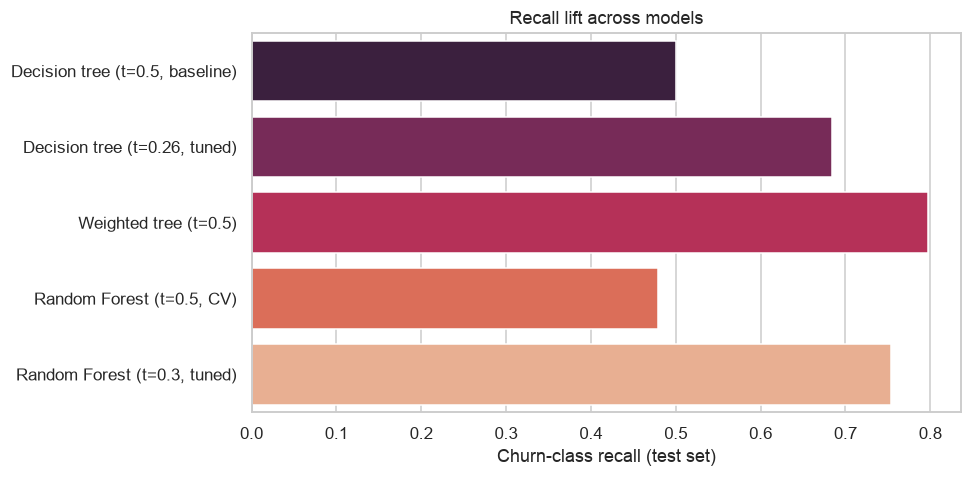

In [20]:
# (b) Class-weighted tree: weight each row by inverse class frequency.
n_tot = train_df.count(); n_pos = train_df.filter(F.col("label") == 1.0).count(); n_neg = n_tot - n_pos
w_pos, w_neg = n_tot / (2 * n_pos), n_tot / (2 * n_neg)
train_w = train_df.withColumn("weight", F.when(F.col("label") == 1.0, F.lit(w_pos)).otherwise(F.lit(w_neg)))
wtree = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=best_depth,
                               seed=RANDOM_SEED, weightCol="weight").fit(train_w)

# (c) Random Forest tuned by 3-fold cross-validation on a small grid.
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
rf = RandomForestClassifier(labelCol="label", featuresCol="features", seed=RANDOM_SEED)
rf_grid = ParamGridBuilder().addGrid(rf.numTrees, [60, 120]).addGrid(rf.maxDepth, [5, 8]).build()
rf_cv = CrossValidator(estimator=rf, estimatorParamMaps=rf_grid, evaluator=auc_cv_eval,
                       numFolds=3, seed=RANDOM_SEED, parallelism=2).fit(train_df)
rf_model = rf_cv.bestModel
print("RF best params: numTrees=%s  maxDepth=%s" % (rf_model.getNumTrees, rf_model.getOrDefault("maxDepth")))

# Threshold-tune the RF on validation too.
rf_val_s = scored(rf_model.transform(val_df))
rf_curve = pd.DataFrame([{"t": t, **churn_scores(rf_val_s, t)} for t in grid])
t_rf = float(rf_curve.loc[rf_curve["f1"].idxmax(), "t"])

# Score every model on the held-out TEST set.
tree_test = scored(model.transform(test_df))
w_test    = scored(wtree.transform(test_df))
rf_test   = scored(rf_model.transform(test_df))
auc_tree, auc_w, auc_rf = (probability_auc(model.transform(test_df)),
                           probability_auc(wtree.transform(test_df)),
                           probability_auc(rf_model.transform(test_df)))

def row_for(name, s, t, a):
    m = churn_scores(s, t)
    return {"model": name, "threshold": t, "accuracy": round(m["acc"], 4),
            "precision_churn": round(m["precision"], 4), "recall_churn": round(m["recall"], 4),
            "f1_churn": round(m["f1"], 4), "auc": round(a, 4)}

rows = [
    ("Decision tree (t=0.5, baseline)", tree_test, 0.5, auc_tree),
    (f"Decision tree (t={t_tree}, tuned)", tree_test, t_tree, auc_tree),
    ("Weighted tree (t=0.5)", w_test, 0.5, auc_w),
    ("Random Forest (t=0.5, CV)", rf_test, 0.5, auc_rf),
    (f"Random Forest (t={t_rf}, tuned)", rf_test, t_rf, auc_rf),
]
comparison = pd.DataFrame([row_for(*r) for r in rows])
print(comparison.to_string(index=False))

plt.figure(figsize=(9, 4.5))
sns.barplot(data=comparison, y="model", x="recall_churn", hue="model", palette="rocket", legend=False)
plt.xlabel("Churn-class recall (test set)"); plt.ylabel("")
plt.title("Recall lift across models"); plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_recall_comparison.png"); plt.show()

recall_improvement = {"comparison": comparison.to_dict(orient="records"),
                      "chosen_threshold_tree": t_tree, "chosen_threshold_rf": t_rf,
                      "class_weights": {"pos": round(w_pos, 3), "neg": round(w_neg, 3)}}

### 5c. Choosing the threshold by business cost

Maximising F1 balances precision and recall *equally*, but the two errors are not equally expensive.
A **missed churner** (false negative) forfeits future value; a **wasted retention offer** (false
positive) costs only the incentive. Because the real costs are not supplied, ratios of **2:1, 5:1 and
10:1** are treated as illustrative sensitivity scenarios. Thresholds are selected on validation and
evaluated once on test; 5:1 is retained as the headline operating point.

 fn_fp_ratio  threshold  tn  fp  fn  tp  recall  precision  accuracy
         2.0       0.36 838 197 124 250  0.6684     0.5593    0.7722
         5.0       0.14 549 486  25 349  0.9332     0.4180    0.6373
        10.0       0.08 379 656   9 365  0.9759     0.3575    0.5280
Headline RF threshold (illustrative FN:FP = 5:1): t = 0.14
  Confusion (TN, FP, FN, TP): 549, 486, 25, 349
  Recall 0.933 | Precision 0.418 | Accuracy 0.637
  Churners caught: 349/374  |  Offers wasted on stayers: 486


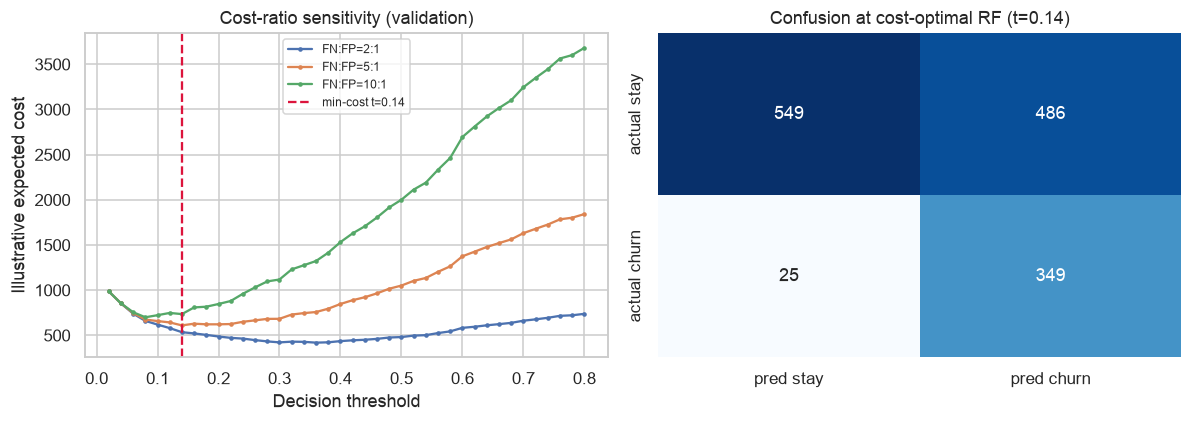

In [21]:
# Sensitivity analysis: missed-churner cost relative to a wasted retention offer.
COST_RATIOS, COST_FP = [2.0, 5.0, 10.0], 1.0

def counts(s, t):
    yhat = (s["p1"] >= t).astype(int); y = s["label"].astype(int)
    tp = int(((yhat == 1) & (y == 1)).sum()); fp = int(((yhat == 1) & (y == 0)).sum())
    fn = int(((yhat == 0) & (y == 1)).sum()); tn = int(((yhat == 0) & (y == 0)).sum())
    return tn, fp, fn, tp

def exp_cost(s, t, cost_fn):
    _, fp, fn, _ = counts(s, t)
    return cost_fn * fn + COST_FP * fp

# Select each threshold on validation, then evaluate it on the untouched test set.
cost_rows, cost_curves = [], {}
for ratio in COST_RATIOS:
    curve = pd.DataFrame([{"t": t, "cost": exp_cost(rf_val_s, t, ratio)} for t in grid])
    threshold = float(curve.loc[curve["cost"].idxmin(), "t"])
    tn_s, fp_s, fn_s, tp_s = counts(rf_test, threshold)
    score = churn_scores(rf_test, threshold)
    cost_rows.append({"fn_fp_ratio": ratio, "threshold": threshold, "tn": tn_s, "fp": fp_s,
                      "fn": fn_s, "tp": tp_s, "recall": score["recall"],
                      "precision": score["precision"], "accuracy": score["acc"]})
    cost_curves[ratio] = curve
cost_sensitivity_df = pd.DataFrame(cost_rows)
headline = cost_sensitivity_df.loc[cost_sensitivity_df["fn_fp_ratio"] == 5.0].iloc[0]
t_cost = float(headline["threshold"])
tn_c, fp_c, fn_c, tp_c = (int(headline[k]) for k in ["tn", "fp", "fn", "tp"])
m_cost = churn_scores(rf_test, t_cost)
print(cost_sensitivity_df.round(4).to_string(index=False))
print(f"Headline RF threshold (illustrative FN:FP = 5:1): t = {t_cost}")
print(f"  Confusion (TN, FP, FN, TP): {tn_c}, {fp_c}, {fn_c}, {tp_c}")
print(f"  Recall {m_cost['recall']:.3f} | Precision {m_cost['precision']:.3f} | Accuracy {m_cost['acc']:.3f}")
print(f"  Churners caught: {tp_c}/{tp_c + fn_c}  |  Offers wasted on stayers: {fp_c}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for ratio, curve in cost_curves.items():
    ax[0].plot(curve["t"], curve["cost"], marker="o", ms=2, label=f"FN:FP={ratio:.0f}:1")
ax[0].axvline(t_cost, ls="--", c="crimson", label=f"min-cost t={t_cost}")
ax[0].set_xlabel("Decision threshold"); ax[0].set_ylabel("Illustrative expected cost")
ax[0].set_title("Cost-ratio sensitivity (validation)"); ax[0].legend(fontsize=8)
cm = np.array([[tn_c, fp_c], [fn_c, tp_c]])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[1],
            xticklabels=["pred stay", "pred churn"], yticklabels=["actual stay", "actual churn"])
ax[1].set_title(f"Confusion at cost-optimal RF (t={t_cost})")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig11_cost_operating_point.png"); plt.show()

cost_sensitivity = cost_sensitivity_df.round(4).to_dict(orient="records")
business_operating_point = {"cost_fn": 5.0, "cost_fp": COST_FP, "threshold": t_cost,
                            "confusion": {"tn": tn_c, "fp": fp_c, "fn": fn_c, "tp": tp_c},
                            "recall": round(m_cost["recall"], 4), "precision": round(m_cost["precision"], 4),
                            "accuracy": round(m_cost["acc"], 4)}

## 6. Task 3 - Handling missing values

The supplied data is almost complete, but in production the *most important* attribute often arrives
with gaps. We take the top attribute from the tree, **simulate ~30% missingness** in it, then impute
and re-fit to measure the impact - mirroring the real decision a data scientist faces.

In [22]:
top_idx = FEATURE_NAMES.index(top_feature)
is_numeric = top_feature in NUMERIC

# Inject the same deterministic 30% missingness rule into each fixed raw partition.
def inject_missing(frame):
    mask = F.pmod(F.xxhash64("customerID", F.lit(RANDOM_SEED + 99)), F.lit(100)) < 30
    return frame.withColumn(top_feature, F.when(mask, F.lit(None)).otherwise(F.col(top_feature)))

tr_missing, va_missing, te_missing = (inject_missing(x) for x in [train_raw, val_raw, test_raw])
n_missing = sum(x.filter(F.col(top_feature).isNull()).count() for x in [tr_missing, va_missing, te_missing])
# Derive the replacement from TRAINING only and apply it to all partitions.
if is_numeric:
    fill = float(tr_missing.approxQuantile(top_feature, [0.5], 0.0)[0])
    impute_desc = f"median imputation ({fill:.2f})"
else:
    fill = (tr_missing.filter(F.col(top_feature).isNotNull()).groupBy(top_feature).count()
            .orderBy(F.desc("count"), F.asc(top_feature)).first()[top_feature])
    impute_desc = f"mode imputation ('{fill}')"
tr_imp, va_imp, te_imp = (x.fillna({top_feature: fill}) for x in [tr_missing, va_missing, te_missing])
print(f"Knocked out {n_missing} ({n_missing/len(clean):.0%}) values of '{top_feature}', imputed via {impute_desc}")

# Fit preprocessing/model on imputed TRAINING and evaluate the same held-out test customer IDs.
prep2 = make_preprocessor(NUMERIC, CATEGORICAL).fit(tr_imp)
tr2 = prep2.transform(tr_imp).select("customerID", "features", "label")
te2 = prep2.transform(te_imp).select("customerID", "features", "label")
model2 = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=best_depth, seed=RANDOM_SEED).fit(tr2)
p2 = model2.transform(te2)
acc2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(p2)
f1_2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(p2)
churn_f1_2 = churn_f1(p2); auc2 = probability_auc(p2)
assert set(te2.select("customerID").toPandas()["customerID"]) == split_ids["test"]
print(f"After 30% missing + train-mode impute: accuracy={acc2:.4f} weightedF1={f1_2:.4f} "
      f"churnF1={churn_f1_2:.4f} AUC={auc2:.4f}")
print(f"Original, same test IDs: accuracy={acc:.4f} weightedF1={f1:.4f} "
      f"churnF1={churn_f1(pred):.4f} AUC={auc:.4f}")

Knocked out 2079 (30%) values of 'Contract', imputed via mode imputation ('Month-to-month')


After 30% missing + train-mode impute: accuracy=0.7786 weightedF1=0.7597 churnF1=0.4851 AUC=0.7912
Original, same test IDs: accuracy=0.7807 weightedF1=0.7736 churnF1=0.5476 AUC=0.8019


**Missing-value strategy.** Because the most important attribute carries most of the model's
signal, dropping rows with gaps would discard ~30% of the data and bias the sample toward complete
records. Instead we derive the **median** (numeric) or **mode** (categorical) from training only and
apply it unchanged to validation/test. C4.5's fractional-instance strategy is a useful theoretical
alternative, but it is not the missing-value behavior implemented by Spark MLlib here. The paired
experiment uses the same customer IDs, so any performance change is attributable to missingness and
imputation rather than a different test sample.

In [23]:
# Persist metrics for the report and print a summary.
metrics = {
    "n_rows": int(len(df)), "n_features": len(FEATURE_NAMES),
    "base_rate_no": round(float(base_rate.get("No")), 4),
    "base_rate_yes": round(float(base_rate.get("Yes")), 4),
    "best_max_depth": int(best_depth),
    "test": {"accuracy": round(acc, 4), "weighted_precision": round(wp, 4),
             "weighted_recall": round(wr, 4), "f1": round(f1, 4), "auc": round(auc, 4)},
    "churn_class": {"recall": round(recall_churn, 4), "precision": round(precision_churn, 4)},
    "confusion": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "most_important_attribute": top_feature,
    "top_features": [{"name": n, "importance": round(float(v), 4)} for n, v in imp[:8]],
    "tenure_totalcharges_corr": round(float(tc_corr), 3),
    "data_quality": data_quality,
    "split_summary": split_summary.to_dict(orient="records"),
    "feature_selection": feature_selection,
    "missing_value_experiment": {
        "feature": top_feature, "pct_missing": 0.30, "impute_method": impute_desc,
        "accuracy_before": round(acc, 4), "accuracy_after": round(acc2, 4),
        "weighted_f1_before": round(f1, 4), "weighted_f1_after": round(f1_2, 4),
        "churn_f1_before": round(churn_f1(pred), 4), "churn_f1_after": round(churn_f1_2, 4),
        "auc_before": round(auc, 4), "auc_after": round(auc2, 4),
        "same_test_customer_ids": True},
    "recall_improvement": recall_improvement,
    "cost_sensitivity": cost_sensitivity,
    "business_operating_point": business_operating_point,
}
(OUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

{
  "n_rows": 7043,
  "n_features": 13,
  "base_rate_no": 0.7346,
  "base_rate_yes": 0.2654,
  "best_max_depth": 6,
  "test": {
    "accuracy": 0.7807,
    "weighted_precision": 0.7703,
    "weighted_recall": 0.7807,
    "f1": 0.7736,
    "auc": 0.8019
  },
  "churn_class": {
    "recall": 0.5,
    "precision": 0.6052
  },
  "confusion": {
    "tn": 913,
    "fp": 122,
    "fn": 187,
    "tp": 187
  },
  "most_important_attribute": "Contract",
  "top_features": [
    {
      "name": "Contract",
      "importance": 0.564
    },
    {
      "name": "tenure",
      "importance": 0.1679
    },
    {
      "name": "TechSupport",
      "importance": 0.1604
    },
    {
      "name": "PaymentMethod",
      "importance": 0.0613
    },
    {
      "name": "StreamingMovies",
      "importance": 0.0189
    },
    {
      "name": "PaperlessBilling",
      "importance": 0.0168
    },
    {
      "name": "MultipleLines",
      "importance": 0.0038
    },
    {
      "name": "gender",
      "importan

## 7. Conclusion

The Spark MLlib decision tree predicts churn modestly above the naive base rate and, more importantly,
gives an interpretable picture of *who* churns: short-tenure customers on month-to-month contracts
paying by electronic check, without tech support. Because the data is imbalanced, the churn-class
recall and F1 (not raw accuracy) are the metrics that matter for a retention use case. The full
written interpretation, including the effectiveness discussion and accuracy-improvement plan, is in
the accompanying report.

In [24]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.


## Academic Integrity Declaration

I declare that except where referenced, the work I am submitting for this assessment task is my own
work. I have read and am aware of the Academic Integrity Policy and Procedure of Torrens University,
Australia.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this notebook:
- Anthropic Claude Opus 4.8

The tool was used to assist with structuring the analysis pipeline, debugging PySpark configuration,
improving code documentation, and framing the churn interpretation. The final analysis, code and
conclusions are my own and I take full responsibility for them.

## References

EMC Education Services. (2015). *Data science and big data analytics: Discovering, analyzing,
visualizing and presenting data*. John Wiley & Sons.

Kaggle. (2020). *Telco customer churn - IBM sample data sets*.
https://www.kaggle.com/blastchar/telco-customer-churn

Marr, B. (2021). *Data strategy: How to profit from a world of big data, analytics and artificial
intelligence* (2nd ed.). Kogan Page.